In [1]:
import os
import glob

import numpy as np
import rasterio
from rasterio.windows import from_bounds, Window
from rasterio.warp import reproject, Resampling

from PIL import Image
import matplotlib.pyplot as plt

In [8]:
PROJECT_ROOT = r"E:\Rasengan\Cloud-Removal"

# Original data
CLOUDY_ROOT = os.path.join(
    PROJECT_ROOT,
    "data",
    "cloudy"
)

CLEAR_ROOT = os.path.join(
    PROJECT_ROOT,
    "data",
    "non-cloudy"
)

# Generated patches
OUTPUT_ROOT = os.path.join(
    PROJECT_ROOT,
    "data",
    "data"
)

OUTPUT_CLOUDY = os.path.join(
    OUTPUT_ROOT,
    "cloudy"
)

OUTPUT_CLEAR = os.path.join(
    OUTPUT_ROOT,
    "non-cloudy"
)

os.makedirs(OUTPUT_CLOUDY, exist_ok=True)
os.makedirs(OUTPUT_CLEAR, exist_ok=True)


# ============================================================
# TEST LOCATION
# ============================================================

LOCATION = "nzb1"

# Team ID for your test
TEAM_ID = "T1"

# Patch settings
PATCH_SIZE = 256
STRIDE = 256


print("Cloudy root :", CLOUDY_ROOT)
print("Clear root  :", CLEAR_ROOT)
print("Output root :", OUTPUT_ROOT)

Cloudy root : E:\Rasengan\Cloud-Removal\data\cloudy
Clear root  : E:\Rasengan\Cloud-Removal\data\non-cloudy
Output root : E:\Rasengan\Cloud-Removal\data\data


In [9]:
def find_tiff(folder):

    tif_files = []

    tif_files.extend(
        glob.glob(os.path.join(folder, "*.tif"))
    )

    tif_files.extend(
        glob.glob(os.path.join(folder, "*.TIF"))
    )

    tif_files.extend(
        glob.glob(os.path.join(folder, "*.tiff"))
    )

    tif_files.extend(
        glob.glob(os.path.join(folder, "*.TIFF"))
    )

    if not tif_files:
        raise FileNotFoundError(
            f"No TIFF file found in:\n{folder}"
        )

    print("\nTIFF files found:")

    for f in tif_files:
        print(" ", os.path.basename(f))

    # For your test, use the first TIFF.
    # Later we can make band selection explicit.
    return tif_files[0]


cloudy_folder = os.path.join(
    CLOUDY_ROOT,
    LOCATION
)

clear_folder = os.path.join(
    CLEAR_ROOT,
    LOCATION
)

cloudy_path = find_tiff(cloudy_folder)
clear_path = find_tiff(clear_folder)

print("\nSelected cloudy:")
print(cloudy_path)

print("\nSelected clear:")
print(clear_path)


TIFF files found:
  BAND2.tif
  BAND3.tif
  BAND4.tif
  BAND2.tif
  BAND3.tif
  BAND4.tif

TIFF files found:
  BAND2.tif
  BAND3.tif
  BAND4.tif
  BAND2.tif
  BAND3.tif
  BAND4.tif

Selected cloudy:
E:\Rasengan\Cloud-Removal\data\cloudy\nzb1\BAND2.tif

Selected clear:
E:\Rasengan\Cloud-Removal\data\non-cloudy\nzb1\BAND2.tif


In [10]:
with rasterio.open(cloudy_path) as src:
    print("===== CLOUDY =====")
    print("Width :", src.width)
    print("Height:", src.height)
    print("Bands :", src.count)
    print("dtype :", src.dtypes[0])
    print("CRS  :", src.crs)
    print("Transform:")
    print(src.transform)


with rasterio.open(clear_path) as src:
    print("\n===== CLEAR =====")
    print("Width :", src.width)
    print("Height:", src.height)
    print("Bands :", src.count)
    print("dtype :", src.dtypes[0])
    print("CRS  :", src.crs)
    print("Transform:")
    print(src.transform)

===== CLOUDY =====
Width : 18130
Height: 16177
Bands : 1
dtype : uint16
CRS  : PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32644"]]
Transform:
| 5.00, 0.00, 219203.94|
| 0.00,-5.00, 2126272.50|
| 0.00, 0.00, 1.00|

===== CLEAR =====
Width : 18097
Height: 16199
Bands : 1
dtype : uint16
CRS  : PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT[

In [11]:
with rasterio.open(cloudy_path) as cloudy_src, \
     rasterio.open(clear_path) as clear_src:

    cloudy_bounds = cloudy_src.bounds
    clear_bounds = clear_src.bounds

    common_left = max(
        cloudy_bounds.left,
        clear_bounds.left
    )

    common_right = min(
        cloudy_bounds.right,
        clear_bounds.right
    )

    common_bottom = max(
        cloudy_bounds.bottom,
        clear_bounds.bottom
    )

    common_top = min(
        cloudy_bounds.top,
        clear_bounds.top
    )

    print("===== COMMON AREA =====")

    print("Left  :", common_left)
    print("Right :", common_right)
    print("Bottom:", common_bottom)
    print("Top   :", common_top)

    overlap_width = common_right - common_left
    overlap_height = common_top - common_bottom

    print("\nOverlap width :", overlap_width, "meters")
    print("Overlap height:", overlap_height, "meters")

===== COMMON AREA =====
Left  : 219203.94308370308
Right : 309683.94308370305
Bottom: 2045522.5
Top   : 2126272.5

Overlap width : 90479.99999999997 meters
Overlap height: 80750.0 meters


In [12]:
with rasterio.open(cloudy_path) as cloudy_src:

    cloudy_window = from_bounds(
        common_left,
        common_bottom,
        common_right,
        common_top,
        transform=cloudy_src.transform
    )

    cloudy_window = (
        cloudy_window
        .round_offsets()
        .round_lengths()
    )

    cloudy_data = cloudy_src.read(
        1,
        window=cloudy_window
    )

    cloudy_transform = rasterio.windows.transform(
        cloudy_window,
        cloudy_src.transform
    )

    cloudy_height, cloudy_width = cloudy_data.shape

    print("===== COMMON PIXEL AREA =====")

    print("Width :", cloudy_width)
    print("Height:", cloudy_height)

    print("Shape :", cloudy_data.shape)

===== COMMON PIXEL AREA =====
Width : 18096
Height: 16150
Shape : (16150, 18096)


In [7]:
PATCH_SIZE = 256
STRIDE = 128

rows = (cloudy_height - PATCH_SIZE) // STRIDE + 1
cols = (cloudy_width - PATCH_SIZE) // STRIDE + 1

print("===== PATCH INFORMATION =====")
print("Rows :", rows)
print("Cols :", cols)
print("Total patches :", rows * cols)

===== PATCH INFORMATION =====
Rows : 125
Cols : 140
Total patches : 17500


In [13]:
with rasterio.open(clear_path) as clear_src:

    clear_aligned = np.zeros(
        (cloudy_height, cloudy_width),
        dtype=clear_src.dtypes[0]
    )

    reproject(
        source=rasterio.band(clear_src, 1),
        destination=clear_aligned,

        src_transform=clear_src.transform,
        src_crs=clear_src.crs,

        dst_transform=cloudy_transform,
        dst_crs=cloudy_src.crs,

        resampling=Resampling.nearest
    )

print("Cloudy shape     :", cloudy_data.shape)
print("Non-cloudy shape :", clear_aligned.shape)

Cloudy shape     : (16150, 18096)
Non-cloudy shape : (16150, 18096)


In [29]:
from PIL import Image
import random
import os
import cv2
import numpy as np

MAX_PATCHES = 1000
MIN_VALID = 0.90

valid_coordinates = []

for row in range(rows):
    for col in range(cols):

        y = row * STRIDE
        x = col * STRIDE

        cloudy_patch = cloudy_data[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ]

        clear_patch = clear_aligned[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ]

        cloudy_valid = np.mean(cloudy_patch != 0)
        clear_valid = np.mean(clear_patch != 0)

        if cloudy_valid >= MIN_VALID and clear_valid >= MIN_VALID:
            valid_coordinates.append(
                (row, col, cloudy_valid, clear_valid)
            )

print("Valid candidate patches:", len(valid_coordinates))

random.seed(42)

if len(valid_coordinates) > MAX_PATCHES:
    selected = random.sample(
        valid_coordinates,
        MAX_PATCHES
    )
else:
    selected = valid_coordinates

pair_names = []

for patch_number, (row, col, cloudy_valid, clear_valid) in enumerate(selected):

    y = row * STRIDE
    x = col * STRIDE

    cloudy_patch = cloudy_data[
        y:y + PATCH_SIZE,
        x:x + PATCH_SIZE
    ]

    clear_patch = clear_aligned[
        y:y + PATCH_SIZE,
        x:x + PATCH_SIZE
    ]

    cloudy_patch = np.clip(
        cloudy_patch,
        0,
        1023
    )

    cloudy_patch = (
        cloudy_patch.astype(np.float32) / 1023.0 * 255
    ).astype(np.uint8)

    clear_patch = np.clip(
        clear_patch,
        0,
        255
    ).astype(np.uint8)

    name = f"{LOCATION}_patch_{patch_number:05d}.png"

    cloudy_output = os.path.join(
        OUTPUT_CLOUDY,
        name
    )

    clear_output = os.path.join(
        OUTPUT_CLEAR,
        name
    )

    cv2.imwrite(
        cloudy_output,
        cloudy_patch
    )

    cv2.imwrite(
        clear_output,
        clear_patch
    )

    pair_names.append(name)

print("Cloudy patches:", len(pair_names))
print("Non-cloudy patches:", len(pair_names))

Valid candidate patches: 13660
Cloudy patches: 1000
Non-cloudy patches: 1000


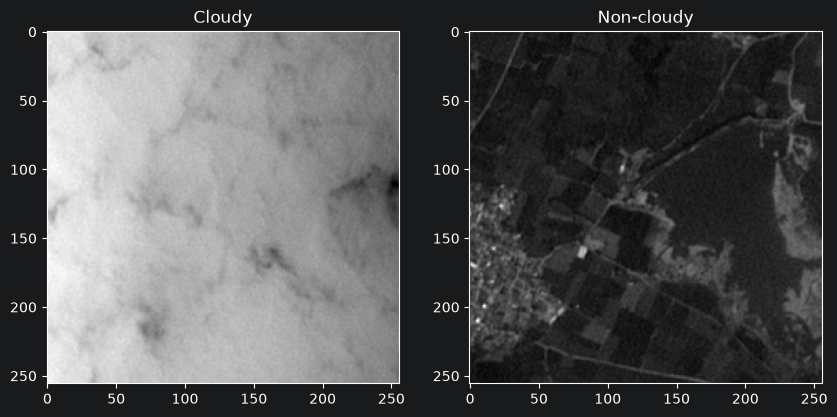

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import os

index = 250

name = pair_names[index]

cloudy_patch = np.array(
    Image.open(os.path.join(OUTPUT_CLOUDY, name))
)

clear_patch = np.array(
    Image.open(os.path.join(OUTPUT_CLEAR, name))
)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cloudy_patch, cmap="gray")
ax[0].set_title("Cloudy")

ax[1].imshow(clear_patch, cmap="gray")
ax[1].set_title("Non-cloudy")

plt.show()

In [21]:
print("Cloudy common:")
print("min :", cloudy_data.min())
print("max :", cloudy_data.max())
print("mean:", cloudy_data.mean())

print("\nFirst 10x10:")
print(cloudy_data[:10, :10])

print("\nNon-cloudy common:")
print("min :", clear_aligned.min())
print("max :", clear_aligned.max())
print("mean:", clear_aligned.mean())

print("\nFirst 10x10:")
print(clear_aligned[:10, :10])

Cloudy common:
min : 0
max : 1023
mean: 377.1113494626526

First 10x10:
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]

Non-cloudy common:
min : 0
max : 239
mean: 72.74187156287896

First 10x10:
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


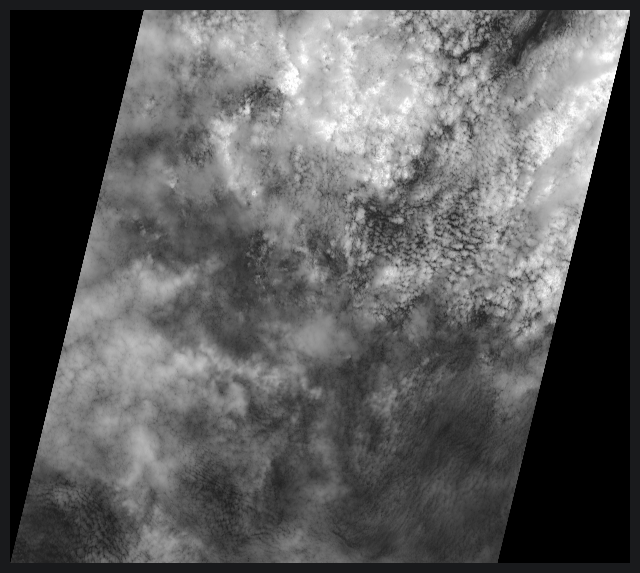

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(cloudy_data, cmap="gray")
plt.axis("off")
plt.show()

In [24]:
rows = (cloudy_data.shape[0] - PATCH_SIZE) // STRIDE + 1
cols = (cloudy_data.shape[1] - PATCH_SIZE) // STRIDE + 1

print(rows, cols)

125 140


row: 0
col: 31
valid: 1.0
min: 455
max: 605
mean: 554.2098693847656


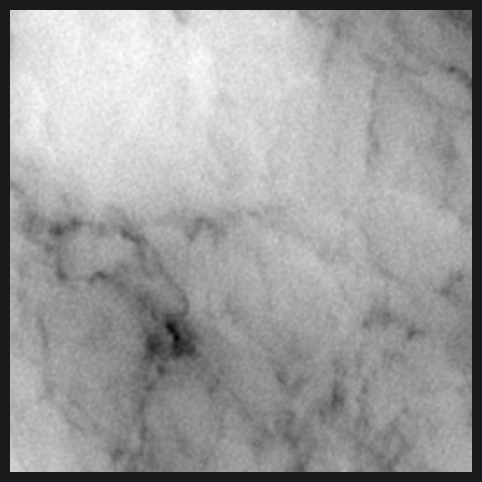

In [25]:
for row in range(rows):
    for col in range(cols):

        y = row * STRIDE
        x = col * STRIDE

        patch = cloudy_data[
            y:y + PATCH_SIZE,
            x:x + PATCH_SIZE
        ]

        valid = np.mean(patch != 0)

        if valid >= 0.90:

            print("row:", row)
            print("col:", col)
            print("valid:", valid)
            print("min:", patch.min())
            print("max:", patch.max())
            print("mean:", patch.mean())

            plt.figure(figsize=(6, 6))
            plt.imshow(patch, cmap="gray")
            plt.axis("off")
            plt.show()

            break

    else:
        continue

    break

Filename: nzb1_patch_00000.png

Cloudy
Shape: (256, 256)
dtype: uint16
Min: 160
Max: 383

Non-cloudy
Shape: (256, 256)
dtype: uint16
Min: 73
Max: 133


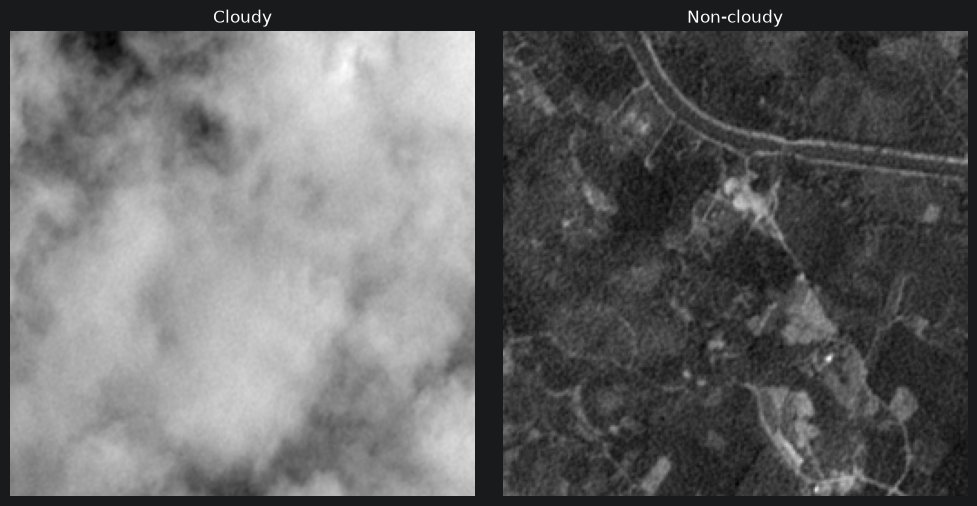

In [26]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

index = 0

name = pair_names[index]

cloudy_path_png = os.path.join(OUTPUT_CLOUDY, name)
clear_path_png = os.path.join(OUTPUT_CLEAR, name)

cloudy_img = np.array(Image.open(cloudy_path_png))
clear_img = np.array(Image.open(clear_path_png))

print("Filename:", name)

print("\nCloudy")
print("Shape:", cloudy_img.shape)
print("dtype:", cloudy_img.dtype)
print("Min:", cloudy_img.min())
print("Max:", cloudy_img.max())

print("\nNon-cloudy")
print("Shape:", clear_img.shape)
print("dtype:", clear_img.dtype)
print("Min:", clear_img.min())
print("Max:", clear_img.max())

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cloudy_img, cmap="gray")
ax[0].set_title("Cloudy")
ax[0].axis("off")

ax[1].imshow(clear_img, cmap="gray")
ax[1].set_title("Non-cloudy")
ax[1].axis("off")

plt.tight_layout()
plt.show()

Shape: (256, 256)
dtype: uint16
min: 160
max: 383


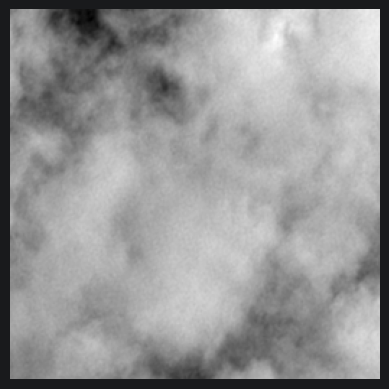

In [28]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(cloudy_path_png, cv2.IMREAD_UNCHANGED)

print("Shape:", img.shape)
print("dtype:", img.dtype)
print("min:", img.min())
print("max:", img.max())

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()